#  프로젝트: 멋진 챗봇 만들기

> **목표**: Transformer 아키텍처를 활용하여 한국어 일상 대화 챗봇을 만든다.
>
>
> **데이터**: songys/Chatbot_data (한국어 일상 대화 Q&A )

---

##  프로젝트 평가 기준 (루브릭)

| 학습 목표 | 평가 기준 |
|---|---|
| 챗봇 훈련데이터 전처리 과정이 체계적으로 진행되었는가? | 전처리와 augmentation이 적절히 수행되어 3만개 가량의 훈련데이터셋이 구축되었다. |
| Transformer 모델을 활용한 챗봇 모델이 과적합을 피해 안정적으로 훈련되었는가? | 과적합을 피할 수 있는 하이퍼파라미터 셋이 적절히 제시되었다. |
| 챗봇이 사용자의 질문에 그럴듯한 형태로 답하는 사례가 있는가? | 주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례가 제출되었다. |

---

##  노트북 구성

1. **환경 설정** — 라이브러리 버전 확인 및 임포트
2. **데이터 다운로드** — ChatbotData.csv → questions, answers
3. **데이터 정제** — `preprocess_sentence()` 정규식 정제
4. **데이터 토큰화** — `build_corpus()` mecab 형태소 분석
5. **Augmentation** — Lexical Substitution으로 3배 증강 (목표: 3만개)
6. **데이터 벡터화** — `<start>`, `<end>` 토큰 추가, vocab 구축
7. **모델 훈련** — Transformer (n_layers=1, d_model=368, n_heads=8 ...)
8. **성능 측정** — BLEU Score + 예문 답변 생성
9. **회고** — 배운 점과 한계

In [1]:
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.2.6
2.3.0
2.7.1+cu118
3.9.4
4.4.0


---

#  1. 데이터 다운로드 & 읽기

[songys/Chatbot_data](https://github.com/songys/Chatbot_data) 
.

이 데이터는 한국어 일상 대화 Q&A 쌍으로 구성:
- **Q**: 질문 (예: "오늘 일찍 일어났더니 피곤하다.")
- **A**: 답변 (예: "푹 쉬어 두세요.")
- **label**: 감정 라벨 (0: 일상, 1: 이별, 2: 사랑) — 우리는 안 씀

질문과 답변을 각각 `questions`, `answers` 변수에 저장해두면
이후 단계에서 소스(인코더 입력) ↔ 타겟(디코더 출력)으로 활용

In [3]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv('ChatbotData.csv')

# 질문(Q)과 답변(A)을 각각 리스트로 분리
questions = df['Q'].tolist()
answers = df['A'].tolist()

print(f"전체 데이터 개수: {len(df):,}쌍")
print(f"questions 개수: {len(questions):,}")
print(f"answers 개수:   {len(answers):,}")
print()
print("DataFrame 미리보기:")
df.head()

전체 데이터 개수: 11,823쌍
questions 개수: 11,823
answers 개수:   11,823

DataFrame 미리보기:


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [6]:
# 질문 & 답변 길이 분포 확인
import numpy as np

q_lens = [len(q) for q in questions]
a_lens = [len(a) for a in answers]

print(" 질문 길이 통계 (문자 수)")
print(f"  최소: {min(q_lens)}, 최대: {max(q_lens)}, 평균: {np.mean(q_lens):.1f}")
print()
print(" 답변 길이 통계 (문자 수)")
print(f"  최소: {min(a_lens)}, 최대: {max(a_lens)}, 평균: {np.mean(a_lens):.1f}")
print()
print("샘플 5개:")

for i in range(5):
    print(f"[{i}] Q: {questions[i]}")
    print(f"    A: {answers[i]}")
    print()

 질문 길이 통계 (문자 수)
  최소: 1, 최대: 56, 평균: 12.9

 답변 길이 통계 (문자 수)
  최소: 1, 최대: 76, 평균: 15.0

샘플 5개:
[0] Q: 12시 땡!
    A: 하루가 또 가네요.

[1] Q: 1지망 학교 떨어졌어
    A: 위로해 드립니다.

[2] Q: 3박4일 놀러가고 싶다
    A: 여행은 언제나 좋죠.

[3] Q: 3박4일 정도 놀러가고 싶다
    A: 여행은 언제나 좋죠.

[4] Q: PPL 심하네
    A: 눈살이 찌푸려지죠.



---

# 2. 데이터 정제

원본 데이터에는 이모티콘, 특수 기호, 의미 없는 문자들이 섞여 있다
`preprocess_sentence()` 함수로 정제

## 조건
1. 영문자의 경우, **모두 소문자**로 변환
2. 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤
   **정규식을 활용하여 모두 제거**

문장부호 양옆에 공백을 추가하는 등 이전과 다르게 생략된 기능들은
우리가 사용할 토크나이저(`mecab`)가 형태소 단위로 자동 분리해주기 때문에
굳이 구현하지 않아도 ㄱㅊ

In [7]:
import re

def preprocess_sentence(sentence):
    """
    문장 정제 함수.
    
    1. 영문자는 모두 소문자로 변환
    2. 한글/영문/숫자/주요 특수문자(.,!?)만 남기고 모두 제거
    3. 양 끝 공백 제거
    """
    # 1) 소문자 변환
    sentence = sentence.lower()
    
    # 2) 한글, 영문, 숫자, 주요 특수문자(. , ! ?)만 남기고 제거
    #    - ㄱ-ㅎ, ㅏ-ㅣ : 자모만 있는 경우 (ㅋㅋ, ㅠㅠ)
    #    - 가-힣 : 완성된 한글 음절
    #    - a-z, 0-9 : 영문 소문자, 숫자
    #    - .,!? : 주요 문장부호
    #    - 공백
    sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-z0-9.,!?\s]", " ", sentence)
    
    # 3) 연속된 공백을 하나로 압축하고 양끝 공백 제거
    sentence = re.sub(r"\s+", " ", sentence).strip()
    
    return sentence

In [8]:
# 다양한 케이스로 정제 함수가 잘 동작하는지 확인
test_sentences = [
    "Hello! 오늘 너무 피곤해요 ㅠㅠ",
    "AI는 정말 흥미로운 분야!!! ",
    "1234 abc ABC 가나다 #$@ ★",
    "여친이 떠났어... 좆같다 ㅋㅋㅋ",
    "오늘 일찍 일어났더니 피곤하다.",
]

print("=" * 60)
for s in test_sentences:
    cleaned = preprocess_sentence(s)
    print(f"원본:   {s}")
    print(f"정제후: {cleaned}")
    print("-" * 60)

원본:   Hello! 오늘 너무 피곤해요 ㅠㅠ
정제후: hello! 오늘 너무 피곤해요 ㅠㅠ
------------------------------------------------------------
원본:   AI는 정말 흥미로운 분야!!! 
정제후: ai는 정말 흥미로운 분야!!!
------------------------------------------------------------
원본:   1234 abc ABC 가나다 #$@ ★
정제후: 1234 abc abc 가나다
------------------------------------------------------------
원본:   여친이 떠났어... 좆같다 ㅋㅋㅋ
정제후: 여친이 떠났어... 좆같다 ㅋㅋㅋ
------------------------------------------------------------
원본:   오늘 일찍 일어났더니 피곤하다.
정제후: 오늘 일찍 일어났더니 피곤하다.
------------------------------------------------------------


---

# 3. 데이터 토큰화

토큰화에는 **KoNLPy의 `mecab` 클래스**를 사용. Mecab은 한국어에 최적화된
형태소 분석기로, 빠르고 정확한 토큰화를 지원

## `build_corpus()` 함수 조건
1. 소스 문장 데이터와 타겟 문장 데이터를 입력으로 받는다
2. 데이터를 앞서 정의한 `preprocess_sentence()` 함수로 정제하고, 토큰화.
3. 토큰화는 `mecab.morphs` 함수를 사용.
4. 토큰의 개수가 일정 길이 이상인 문장은 데이터에서 제외.
5. 중복되는 문장은 데이터에서 제외
   소스 ↔ 타겟 쌍을 비교하지 않고, 소스는 소스대로, 타겟은 타겟대로 검사
   (소스 중복 행이 발견되면 그 행의 타겟도 같이 버린다. — 정렬 유지!)

In [11]:
!pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 4.4 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 48.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-mecab-ko]dic]


In [13]:
# python-mecab-ko 사용
# konlpy의 Mecab이랑 API가 거의 동일 (morphs, nouns, pos 등 그대로)
from mecab import MeCab

mecab = MeCab()

print(" Mecab 로드 성공!")
print(f"테스트 토큰화: {mecab.morphs('오늘은 정말 피곤하다.')}")
print(f"품사 태깅:    {mecab.pos('오늘은 정말 피곤하다.')}")

 Mecab 로드 성공!
테스트 토큰화: ['오늘', '은', '정말', '피곤', '하', '다', '.']
품사 태깅:    [('오늘', 'NNG'), ('은', 'JX'), ('정말', 'MAG'), ('피곤', 'NNG'), ('하', 'XSA'), ('다', 'EF'), ('.', 'SF')]


In [15]:
def build_corpus(src_data, tgt_data, mecab, max_tokens=40):
    """
    소스/타겟 문장 쌍을 정제 + 토큰화하고, 너무 길거나 중복인 쌍은 제거.
    
    조건:
    - 정제: preprocess_sentence() 사용
    - 토큰화: mecab.morphs() 사용
    - 토큰 개수 > max_tokens 이면 제외
    - 중복 문장 제외 (source는 source끼리, target은 target끼리 검사)
      단, 중복 행 발견 시 짝이 되는 반대편도 같이 제외해 정렬을 유지함
    """
    assert len(src_data) == len(tgt_data), "소스와 타겟 개수가 같아야한다."
    
    src_corpus = []
    tgt_corpus = []
    
    src_seen = set()  # 소스 중복 체크용
    tgt_seen = set()  # 타겟 중복 체크용
    
    for src, tgt in zip(src_data, tgt_data):
        # 1) 정제
        src = preprocess_sentence(src)
        tgt = preprocess_sentence(tgt)
        
        # 2) 토큰화
        src_tokens = mecab.morphs(src)
        tgt_tokens = mecab.morphs(tgt)
        
        # 3) 길이 필터
        if len(src_tokens) > max_tokens: continue
        if len(tgt_tokens) > max_tokens: continue
        if len(src_tokens) == 0 or len(tgt_tokens) == 0: continue
        
        # 4) 중복 필터 (튜플로 변환해서 set에 체크)
        src_key = tuple(src_tokens)
        tgt_key = tuple(tgt_tokens)
        if src_key in src_seen: continue
        if tgt_key in tgt_seen: continue
        
        src_seen.add(src_key)
        tgt_seen.add(tgt_key)
        
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)
    
    return src_corpus, tgt_corpus

In [16]:
# questions ↔ que_corpus, answers ↔ ans_corpus
que_corpus, ans_corpus = build_corpus(questions, answers, mecab, max_tokens=40)

print(f"원본 데이터: {len(questions):,}쌍")
print(f"정제/토큰화 후: {len(que_corpus):,}쌍")
print(f"제거된 쌍 수: {len(questions) - len(que_corpus):,}쌍")
print()
print("=" * 60)
print("토큰화 샘플 5개")
print("=" * 60)
for i in range(5):
    print(f"[{i}] Q tokens: {que_corpus[i]}")
    print(f"    A tokens: {ans_corpus[i]}")
    print()

원본 데이터: 11,823쌍
정제/토큰화 후: 7,683쌍
제거된 쌍 수: 4,140쌍

토큰화 샘플 5개
[0] Q tokens: ['12', '시', '땡', '!']
    A tokens: ['하루', '가', '또', '가', '네요', '.']

[1] Q tokens: ['1', '지망', '학교', '떨어졌', '어']
    A tokens: ['위로', '해', '드립니다', '.']

[2] Q tokens: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
    A tokens: ['여행', '은', '언제나', '좋', '죠', '.']

[3] Q tokens: ['ppl', '심하', '네']
    A tokens: ['눈살', '이', '찌푸려', '지', '죠', '.']

[4] Q tokens: ['sd', '카드', '망가졌', '어']
    A tokens: ['다시', '새로', '사', '는', '게', '마음', '편해요', '.']



In [17]:
import numpy as np

q_lens = [len(c) for c in que_corpus]
a_lens = [len(c) for c in ans_corpus]

print(" 질문 토큰 길이")
print(f"  최소: {min(q_lens)}, 최대: {max(q_lens)}, 평균: {np.mean(q_lens):.1f}")
print(f"  95%분위수: {np.percentile(q_lens, 95):.0f}")
print()
print(" 답변 토큰 길이")  
print(f"  최소: {min(a_lens)}, 최대: {max(a_lens)}, 평균: {np.mean(a_lens):.1f}")
print(f"  95%분위수: {np.percentile(a_lens, 95):.0f}")

 질문 토큰 길이
  최소: 1, 최대: 32, 평균: 7.5
  95%분위수: 15

 답변 토큰 길이
  최소: 1, 최대: 40, 평균: 8.7
  95%분위수: 15


---

# 4. Augmentation

우리에게 주어진 데이터는 **1만 개 가량으로 적은 편**. 이럴 때 사용할 수 있는
테크닉이 **Lexical Substitution(어휘 치환)** — 문장 내 단어를 의미가 비슷한 다른 단어로
바꿔서 새로운 학습 샘플을 만드는 방법.

## 사용할 도구
- [Kyubyong/wordvectors](https://github.com/Kyubyong/wordvectors)의 **Korean (w)** — Word2Vec
  으로 사전 학습된 한국어 임베딩 모델
- 파일명: `ko.bin`

## 전체 구성
- 원본 `que_corpus` ↔ 원본 `ans_corpus` (1배)
- **Augmented `que_corpus`** ↔ 원본 `ans_corpus` (1배 → 질문만 치환)
- 원본 `que_corpus` ↔ **Augmented `ans_corpus`** (1배 → 답변만 치환)

→ 총 **3배**, 약 3만 개의 훈련 데이터 완성!

In [25]:
import os

ko_bin_path = "ko.bin"

if os.path.exists(ko_bin_path):
    size_mb = os.path.getsize(ko_bin_path) / 1024 / 1024
    print(f"✅ ko.bin이 이미 있어요. ({size_mb:.1f} MB)")
else:
    print(" ko.bin 다운로드 중...")
    # Kyubyong/wordvectors의 ko.bin 미러 (Hugging Face hosted)
    !wget -q https://huggingface.co/Kyubyong/wordvectors-ko/resolve/main/ko.bin -O ko.bin
    
    if os.path.exists(ko_bin_path):
        size_mb = os.path.getsize(ko_bin_path) / 1024 / 1024
        print(f" 다운로드 완료! ({size_mb:.1f} MB)")
    else:
        print(" 다운로드 실패.")

✅ ko.bin이 이미 있어요. (48.3 MB)


In [29]:
# Kyubyong ko.bin은 gensim 3.x 모델이라 4.x에서 호환 불가
# → 우리 챗봇 corpus로 직접 Word2Vec 학습 (augmentation 목적상 충분)

from gensim.models import Word2Vec

# 학습 데이터: 질문 + 답변 토큰 리스트 전체
all_sentences = que_corpus + ans_corpus
print(f"학습 문장 수: {len(all_sentences):,}")

# Word2Vec 학습 (작은 데이터 → 가벼운 설정)
w2v = Word2Vec(
    sentences=all_sentences,
    vector_size=100,    # 임베딩 차원
    window=5,           # 윈도우 크기
    min_count=2,        # 2번 이상 등장한 단어만 학습
    workers=4,          # 병렬 처리
    sg=1,               # skip-gram 사용 (CBOW=0)
    epochs=20,
)

print(f"\n✅ Word2Vec 학습 완료")
print(f"  단어 수: {len(w2v.wv.key_to_index):,}")
print(f"  벡터 차원: {w2v.wv.vector_size}")
print()

# 우리 데이터에 자주 등장하는 단어로 테스트
test_words = ["사랑", "피곤", "오늘", "행복", "친구"]
for tw in test_words:
    if tw in w2v.wv.key_to_index:
        sims = w2v.wv.most_similar(tw, topn=5)
        print(f"'{tw}'과 유사한 단어: {[w for w, _ in sims]}")
    else:
        print(f"'{tw}' → vocab에 없음 (min_count=2 필터로 제외됨)")

학습 문장 수: 15,366

✅ Word2Vec 학습 완료
  단어 수: 3,550
  벡터 차원: 100

'사랑'과 유사한 단어: ['소중', '존재', '변해요', '장학금', '다정']
'피곤'과 유사한 단어: ['허전', '싱숭생숭', '답답', '놀랐', '헛헛']
'오늘'과 유사한 단어: ['어제', '하루', '저녁', '퇴근길', 'ㅎㅎ']
'행복'과 유사한 단어: ['평온', '성숙', '불행', '비참', '알콩달콩']
'친구'과 유사한 단어: ['남자', '간대', '여자', '쿨', '이뻐서']


In [30]:
import random

def lexical_sub(tokens, w2v, sub_prob=0.2, topn=5):
    """
    Lexical Substitution: 문장 내 일부 토큰을 유사 단어로 치환.
    
    Args:
        tokens: 토큰 리스트 (예: ['오늘', '은', '피곤', '하', '다'])
        w2v: 학습된 Word2Vec 모델
        sub_prob: 각 토큰을 치환할 확률 (0.2 → 평균 20% 토큰 치환)
        topn: 유사 단어 후보 개수
    
    Returns:
        치환된 새 토큰 리스트
    """
    new_tokens = []
    
    for tok in tokens:
        # 일정 확률로, 그리고 w2v 사전에 있는 단어만 치환 시도
        if tok in w2v.wv.key_to_index and random.random() < sub_prob:
            try:
                similar = w2v.wv.most_similar(tok, topn=topn)
                # 후보 중 랜덤 선택
                substitute = random.choice(similar)[0]
                new_tokens.append(substitute)
            except KeyError:
                new_tokens.append(tok)
        else:
            new_tokens.append(tok)
    
    return new_tokens


# 함수 테스트
random.seed(42)
sample = que_corpus[0]
print(f"원본:    {sample}")
print(f"치환 #1: {lexical_sub(sample, w2v)}")
print(f"치환 #2: {lexical_sub(sample, w2v)}")
print(f"치환 #3: {lexical_sub(sample, w2v)}")

원본:    ['12', '시', '땡', '!']
치환 #1: ['12', '즐거운', '땡', '파이팅']
치환 #2: ['12', '시', '쟁이', '파이팅']
치환 #3: ['12', '시', '파이팅', '!']


In [31]:
from tqdm.notebook import tqdm

random.seed(42)  # 재현성

# (1) 원본 데이터 그대로
aug_que_corpus = list(que_corpus)
aug_ans_corpus = list(ans_corpus)

# (2) que_corpus만 augmentation → 원본 ans_corpus와 짝
print("(2/3) 질문 augmentation 중...")
for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    aug_que_corpus.append(lexical_sub(q, w2v))
    aug_ans_corpus.append(a)  # 답변은 원본 그대로

# (3) ans_corpus만 augmentation → 원본 que_corpus와 짝
print("(3/3) 답변 augmentation 중...")
for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus)):
    aug_que_corpus.append(q)  # 질문은 원본 그대로
    aug_ans_corpus.append(lexical_sub(a, w2v))

# 변수 이름을 통일 - 이후 단계에서 que_corpus, ans_corpus라는 이름으로 사용
que_corpus = aug_que_corpus
ans_corpus = aug_ans_corpus

print()
print(f"✅ Augmentation 완료!")
print(f"  최종 데이터: {len(que_corpus):,}쌍 (목표: ~30,000)")

(2/3) 질문 augmentation 중...


  0%|          | 0/7683 [00:00<?, ?it/s]

(3/3) 답변 augmentation 중...


  0%|          | 0/7683 [00:00<?, ?it/s]


✅ Augmentation 완료!
  최종 데이터: 23,049쌍 (목표: ~30,000)


In [32]:
N = len(que_corpus) // 3  # 원본 1/3 지점

print(f"전체 {len(que_corpus):,}쌍 = 원본 {N:,} + Q증강 {N:,} + A증강 {N:,}")
print()
print("=" * 70)
print(" 원본 (인덱스 0)")
print(f"  Q: {que_corpus[0]}")
print(f"  A: {ans_corpus[0]}")
print()
print(f" Q만 증강 (인덱스 {N})")
print(f"  Q: {que_corpus[N]}      ← Q 치환됨")
print(f"  A: {ans_corpus[N]}      ← A 원본")
print()
print(f" A만 증강 (인덱스 {2*N})")
print(f"  Q: {que_corpus[2*N]}      ← Q 원본")
print(f"  A: {ans_corpus[2*N]}      ← A 치환됨")

전체 23,049쌍 = 원본 7,683 + Q증강 7,683 + A증강 7,683

 원본 (인덱스 0)
  Q: ['12', '시', '땡', '!']
  A: ['하루', '가', '또', '가', '네요', '.']

 Q만 증강 (인덱스 7683)
  Q: ['12', '즐거운', '땡', '파이팅']      ← Q 치환됨
  A: ['하루', '가', '또', '가', '네요', '.']      ← A 원본

 A만 증강 (인덱스 15366)
  Q: ['12', '시', '땡', '!']      ← Q 원본
  A: ['하루', '쿨', '또', '쿨', '네요', '.']      ← A 치환됨


---

# 5. 데이터 벡터화

타겟 데이터인 `ans_corpus`는 아직 `<start>`, `<end>` 토큰이 없다... 디코더가
"문장 시작/끝"을 알 수 있도록 추가

```python
# 예시
sample = ["12", "시", "땡", "!"]
print([""] + sample + [""])
# → ['', '12', '시', '땡', '!', '']
```

## 작업 순서
1. 타겟 데이터 전체에 `<start>` 토큰과 `<end>` 토큰 추가
2. **챗봇 훈련 데이터의 가장 큰 특징은 소스와 타겟이 같은 언어**
   → Embedding 층을 **공유**(shared embedding)할 수 있어 파라미터 절약 + 성능 향상
3. `que_corpus`와 결합하여 **전체 데이터에 대한 단어 사전 구축**
4. 정수 인코딩 + 패딩 → `enc_train`, `dec_train` 텐서 완성

In [33]:
# Step 5-1. ans_corpus의 모든 문장 앞뒤에 <start>, <end> 추가
ans_corpus = [["<start>"] + sent + ["<end>"] for sent in ans_corpus]

# 잘 추가됐는지 확인
print("✅ <start>/<end> 토큰 추가 완료")
print()
for i in range(3):
    print(f"[{i}] Q: {que_corpus[i]}")
    print(f"    A: {ans_corpus[i]}")
    print()

✅ <start>/<end> 토큰 추가 완료

[0] Q: ['12', '시', '땡', '!']
    A: ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

[1] Q: ['1', '지망', '학교', '떨어졌', '어']
    A: ['<start>', '위로', '해', '드립니다', '.', '<end>']

[2] Q: ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
    A: ['<start>', '여행', '은', '언제나', '좋', '죠', '.', '<end>']



In [34]:
# Step 5-2. 단어 사전(vocab) 구축 - 소스/타겟 공유
from collections import Counter

# 모든 토큰 모으기 (Q + A 통합)
counter = Counter()
for sent in que_corpus + ans_corpus:
    counter.update(sent)

print(f"전체 unique 토큰 수: {len(counter):,}")

# 특수 토큰 정의 (순서 중요!)
#  <pad>: 패딩용 (loss 계산 시 무시)
#  <unk>: 모르는 단어
#  <start>: 디코더 입력 시작
#  <end>: 디코더 출력 종료
SPECIAL_TOKENS = ["<pad>", "<unk>", "<start>", "<end>"]

# vocab 만들기: 특수 토큰 먼저, 그 다음 빈도순
vocab_list = list(SPECIAL_TOKENS)
for word, _ in counter.most_common():
    if word not in SPECIAL_TOKENS:
        vocab_list.append(word)

# 토큰 → ID 매핑
word2idx = {word: i for i, word in enumerate(vocab_list)}
idx2word = {i: word for word, i in word2idx.items()}

VOCAB_SIZE = len(word2idx)
PAD_ID   = word2idx["<pad>"]    # 0
UNK_ID   = word2idx["<unk>"]    # 1
START_ID = word2idx["<start>"]  # 2
END_ID   = word2idx["<end>"]    # 3

print(f"\n✅ Vocab 구축 완료")
print(f"  전체 단어 수 (특수 토큰 포함): {VOCAB_SIZE:,}")
print(f"  <pad>={PAD_ID}, <unk>={UNK_ID}, <start>={START_ID}, <end>={END_ID}")
print(f"\n  자주 등장하는 단어 TOP 10:")
for word, count in counter.most_common(10):
    print(f"    {word}: {count:,}회 (id={word2idx[word]})")

전체 unique 토큰 수: 6,257

✅ Vocab 구축 완료
  전체 단어 수 (특수 토큰 포함): 6,259
  <pad>=0, <unk>=1, <start>=2, <end>=3

  자주 등장하는 단어 TOP 10:
    .: 26,459회 (id=4)
    <start>: 23,049회 (id=2)
    <end>: 23,049회 (id=3)
    이: 9,987회 (id=5)
    는: 9,374회 (id=6)
    하: 9,233회 (id=7)
    을: 5,876회 (id=8)
    가: 5,218회 (id=9)
    좋: 4,594회 (id=10)
    세요: 4,532회 (id=11)


In [35]:
# Step 5-3. 토큰 리스트 → 정수 ID 시퀀스 → 패딩

import numpy as np

# (a) 최대 길이 결정: 95% 분위수 기준 (이상치 영향 최소화)
all_lens = [len(s) for s in que_corpus + ans_corpus]
MAX_LEN = int(np.percentile(all_lens, 99)) + 1   # 여유 +1
print(f"99% 분위수 기준 최대 길이: {MAX_LEN}")

def encode_and_pad(corpus, max_len, word2idx, pad_id=0, unk_id=1):
    """토큰 리스트들을 (N, max_len) 모양의 정수 텐서로 변환."""
    encoded = []
    for sent in corpus:
        # 정수 변환
        ids = [word2idx.get(tok, unk_id) for tok in sent]
        # 길이 잘라내기 + 패딩
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [pad_id] * (max_len - len(ids))
        encoded.append(ids)
    return np.array(encoded, dtype=np.int64)

# (b) 변환 실행
enc_train = encode_and_pad(que_corpus, MAX_LEN, word2idx, PAD_ID, UNK_ID)
dec_train = encode_and_pad(ans_corpus, MAX_LEN, word2idx, PAD_ID, UNK_ID)

print(f"\n✅ 벡터화 완료")
print(f"  enc_train.shape: {enc_train.shape}")
print(f"  dec_train.shape: {dec_train.shape}")
print(f"  dtype: {enc_train.dtype}")

99% 분위수 기준 최대 길이: 22

✅ 벡터화 완료
  enc_train.shape: (23049, 22)
  dec_train.shape: (23049, 22)
  dtype: int64


In [37]:
# 변환 결과 샘플 확인
print(" 샘플 0번 변환 결과")
print(f"원본 Q tokens: {que_corpus[0]}")
print(f"enc_train[0]:  {enc_train[0]}")
print(f"  ↳ 디코딩:    {[idx2word[i] for i in enc_train[0] if i != PAD_ID]}")
print()
print(f"원본 A tokens: {ans_corpus[0]}")
print(f"dec_train[0]:  {dec_train[0]}")
print(f"  ↳ 디코딩:    {[idx2word[i] for i in dec_train[0] if i != PAD_ID]}")

# 통계 확인
print(f"\n 패딩 통계")
non_pad_q = (enc_train != PAD_ID).sum(axis=1).mean()
non_pad_a = (dec_train != PAD_ID).sum(axis=1).mean()
print(f"  enc_train 평균 실제 길이: {non_pad_q:.1f} / {MAX_LEN}")
print(f"  dec_train 평균 실제 길이: {non_pad_a:.1f} / {MAX_LEN}")
print(f"  → 패딩 비율이 너무 높지 않으면 OK")

 샘플 0번 변환 결과
원본 Q tokens: ['12', '시', '땡', '!']
enc_train[0]:  [2402  214 3129  107    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
  ↳ 디코딩:    ['12', '시', '땡', '!']

원본 A tokens: ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']
dec_train[0]:  [  2 273   9 142   9  39   4   3   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]
  ↳ 디코딩:    ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

 패딩 통계
  enc_train 평균 실제 길이: 7.5 / 22
  dec_train 평균 실제 길이: 10.6 / 22
  → 패딩 비율이 너무 높지 않으면 OK


---

# 6. 훈련하기

번역기 프로젝트에서 정의한 Transformer 클래스를 그대로 활용합니다.
다만 우리 데이터 크기가 작으므로 **하이퍼파라미터 튜닝으로 과적합을 회피**

## 핵심 결정 사항
- **`n_layers = 1`**: 데이터가 작아서(~3만) 얕은 모델로 시작 논문6 번역기2 
- **`d_model = 368`**: 임베딩 차원 (논문 512보다 작게)
- **`dropout = 0.2`**: 정규화 강화(과적합 방지)
- **공유 임베딩(`shared=True`)**: 챗봇은 Q/A가 같은 한국어 → 임베딩 공유로 파라미터 절약

## 6.1 모델 정의 (번역기 코드 재사용)

PositionalEncoding → MultiHeadAttention → Encoder/DecoderLayer → 전체 Transformer

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ───── 1. Positional Encoding ─────
class PositionalEncoding(nn.Module):
    """sin/cos 기반 위치 인코딩."""
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * 
                        (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# ───── 2. Multi-Head Attention ─────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        # (B, L, d_model) → (B, n_heads, L, d_k)
        Q = self.W_q(q).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 1, -1e9)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)
        
        # Concat heads
        out = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.W_o(out), attn


# ───── 3. Position-wise FFN ─────
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))


# ───── 4. Encoder Layer ─────
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask):
        # Pre-LN style: norm → sublayer → residual
        attn_out, attn_w = self.self_attn(self.norm1(x), self.norm1(x), 
                                          self.norm1(x), mask)
        x = x + self.dropout(attn_out)
        ffn_out = self.ffn(self.norm2(x))
        x = x + self.dropout(ffn_out)
        return x, attn_w


# ───── 5. Decoder Layer ─────
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, enc_out, causal_mask, padding_mask):
        # Self-attention (causal mask)
        sa_out, dec_attn = self.self_attn(self.norm1(x), self.norm1(x), 
                                           self.norm1(x), causal_mask)
        x = x + self.dropout(sa_out)
        # Cross-attention (encoder padding mask)
        ca_out, dec_enc_attn = self.cross_attn(self.norm2(x), enc_out, 
                                                enc_out, padding_mask)
        x = x + self.dropout(ca_out)
        # FFN
        x = x + self.dropout(self.ffn(self.norm3(x)))
        return x, dec_attn, dec_enc_attn


# ───── 6. Encoder / Decoder ─────
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
    def forward(self, x, mask):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask)
            attns.append(attn)
        return x, attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
    def forward(self, x, enc_out, causal_mask, padding_mask):
        dec_attns, dec_enc_attns = [], []
        for layer in self.layers:
            x, da, dea = layer(x, enc_out, causal_mask, padding_mask)
            dec_attns.append(da)
            dec_enc_attns.append(dea)
        return x, dec_attns, dec_enc_attns


# ───── 7. Transformer (전체) ─────
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len=200,
                 dropout=0.1, shared=True):
        super().__init__()
        self.d_model = d_model
        
        # 임베딩 (공유 옵션)
        if shared:
            assert src_vocab_size == tgt_vocab_size, "공유하려면 vocab 같아야!"
            self.src_emb = nn.Embedding(src_vocab_size, d_model)
            self.tgt_emb = self.src_emb       # 인코더-디코더 임베딩 공유
        else:
            self.src_emb = nn.Embedding(src_vocab_size, d_model)
            self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model)
        
        self.pos_enc = PositionalEncoding(d_model, max_len=pos_len)
        self.dropout = nn.Dropout(dropout)
        
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        
        # 최종 출력층
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        if shared:
            self.fc_out.weight = self.tgt_emb.weight   # weight tying
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def encode(self, src, src_mask):
        x = self.src_emb(src) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_enc(x))
        return self.encoder(x, src_mask)
    
    def decode(self, tgt, enc_out, causal_mask, padding_mask):
        x = self.tgt_emb(tgt) * math.sqrt(self.d_model)
        x = self.dropout(self.pos_enc(x))
        return self.decoder(x, enc_out, causal_mask, padding_mask)
    
    def forward(self, src, tgt, src_mask, causal_mask, padding_mask):
        enc_out, enc_attns = self.encode(src, src_mask)
        dec_out, dec_attns, dec_enc_attns = self.decode(
            tgt, enc_out, causal_mask, padding_mask)
        logits = self.fc_out(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns


print("✅ Transformer 모델 클래스 정의 완료")

✅ Transformer 모델 클래스 정의 완료


In [39]:
def generate_masks(src, tgt, pad_id=0):
    """
    src: (B, S) 인코더 입력
    tgt: (B, T) 디코더 입력 (gold[:-1])
    
    Returns:
        src_mask: (B, 1, 1, S)  — 인코더 self-attn (PAD 마스킹)
        causal_mask: (B, 1, T, T) — 디코더 self-attn (causal + PAD)
        cross_mask: (B, 1, 1, S) — 디코더 cross-attn (인코더 PAD 마스킹)
    
    컨벤션: 1 = 가려라 (masked_fill에서 1인 곳을 -inf로)
    """
    # 1. 인코더 padding mask
    src_mask = (src == pad_id).unsqueeze(1).unsqueeze(2).long()  # (B,1,1,S)
    
    # 2. 디코더 padding mask
    tgt_pad_mask = (tgt == pad_id).unsqueeze(1).unsqueeze(2).long()  # (B,1,1,T)
    
    # 3. Causal mask (미래 토큰 못 보게)
    T = tgt.size(1)
    causal = torch.triu(torch.ones(T, T, device=tgt.device), diagonal=1).long()
    causal = causal.unsqueeze(0).unsqueeze(0)  # (1,1,T,T)
    
    # 디코더 self-attn: causal OR padding
    causal_mask = torch.maximum(causal, tgt_pad_mask)
    
    # 4. Cross-attn은 인코더 패딩만
    cross_mask = src_mask
    
    return src_mask, causal_mask, cross_mask


# 빠른 테스트
test_src = torch.tensor([[5, 6, 7, 0, 0]])  # 마지막 2개 PAD
test_tgt = torch.tensor([[2, 8, 9, 0, 0]])
sm, cm, xm = generate_masks(test_src, test_tgt)
print(f"src_mask shape: {sm.shape}")
print(f"causal_mask shape: {cm.shape}")
print(f"cross_mask shape: {xm.shape}")
print(f"\ncausal_mask[0,0] (1=가림):\n{cm[0,0]}")

src_mask shape: torch.Size([1, 1, 1, 5])
causal_mask shape: torch.Size([1, 1, 5, 5])
cross_mask shape: torch.Size([1, 1, 1, 5])

causal_mask[0,0] (1=가림):
tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 1, 1]])


---

## 6.2 학습 준비

학습을 시작하기 전 필요한 4가지를 셋업해요:

| 항목 | 역할 |
|---|---|
| **하이퍼파라미터** | 모델 크기 및 학습 설정 |
| **Optimizer (Adam)** | 가중치 업데이트 (β1=0.9, β2=0.98, eps=1e-9) |
| **LR Scheduler** | Warmup + Inverse Square Root Decay (원 논문 방식) |
| **Loss (Label Smoothing)** | 모델이 너무 확신하지 않게 → 일반화 ↑ |

### Learning Rate 공식

$$lr = d_{model}^{-0.5} \times \min(step^{-0.5},\ step \times warmup^{-1.5})$$

- Warmup 구간 (0 ~ 1000 step): lr 0에서 천천히 올림 → 초기 안정화
- Decay 구간 (1000 step ~): lr 천천히 낮춤 → 미세 조정



In [40]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ───── 모델 하이퍼파라미터 (가이드 그대로) ─────
N_LAYERS = 1
D_MODEL = 368
N_HEADS = 8
D_FF = 1024
DROPOUT = 0.2
POS_LEN = 200          # MAX_LEN보다 충분히 큰 값

# ───── 학습 하이퍼파라미터 (가이드 그대로) ─────
BATCH_SIZE = 64
N_EPOCHS = 10
WARMUP_STEPS = 1000

# ───── 모델 인스턴스화 ─────
# 챗봇은 Q/A가 같은 한국어 → shared=True로 임베딩 공유
transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,   # 공유 vocab이므로 동일
    pos_len=POS_LEN,
    dropout=DROPOUT,
    shared=True,                 # 임베딩 + weight tying
).to(device)

# 파라미터 개수 확인
n_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"\n✅ Transformer 인스턴스화 완료")
print(f"  학습 가능 파라미터: {n_params:,}개 (약 {n_params/1e6:.2f}M)")
print(f"  Vocab size: {VOCAB_SIZE:,}")

Device: cuda
GPU: Tesla T4

✅ Transformer 인스턴스화 완료
  학습 가능 파라미터: 5,452,867개 (약 5.45M)
  Vocab size: 6,259


In [41]:
import math

class TransformerLRScheduler(torch.optim.lr_scheduler._LRScheduler):
    """
    원 논문의 Warmup + Inverse Square Root Decay 스케줄러.
    
    lr = d_model^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
    """
    def __init__(self, optimizer, d_model, warmup_steps, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super().__init__(optimizer, last_epoch)
    
    def get_lr(self):
        step = max(1, self._step_count)
        scale = (self.d_model ** -0.5) * min(
            step ** -0.5,
            step * (self.warmup_steps ** -1.5)
        )
        return [scale for _ in self.optimizer.param_groups]


# ───── Optimizer (논문 권장 설정) ─────
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1.0,                # scheduler가 덮어쓰니까 placeholder
    betas=(0.9, 0.98),
    eps=1e-9
)

# ───── Scheduler ─────
scheduler = TransformerLRScheduler(optimizer, D_MODEL, WARMUP_STEPS)

print("✅ Optimizer & Scheduler 셋업 완료")
print(f"  Optimizer: Adam (β1=0.9, β2=0.98, eps=1e-9)")
print(f"  Scheduler: Warmup({WARMUP_STEPS}) + Inverse Sqrt Decay")

✅ Optimizer & Scheduler 셋업 완료
  Optimizer: Adam (β1=0.9, β2=0.98, eps=1e-9)
  Scheduler: Warmup(1000) + Inverse Sqrt Decay


✅ Label Smoothing Loss 셋업 완료 (ε=0.1)


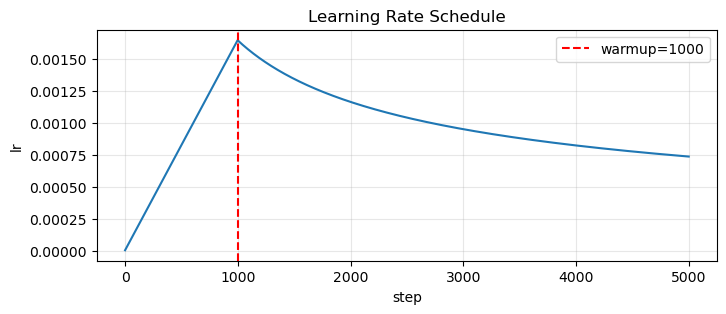

최대 LR: 0.001648 (step 999에서)


In [42]:
class LabelSmoothingLoss(nn.Module):
    """
    Label Smoothing Cross-Entropy.
    정답을 100%가 아닌 (1-ε)%로, 나머지 ε%를 다른 vocab에 균등 분배.
    → 모델이 과도하게 확신하지 않도록 → 일반화 향상.
    """
    def __init__(self, vocab_size, pad_id=0, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing
    
    def forward(self, pred, target):
        # pred: (B, T, V), target: (B, T)
        B, T, V = pred.size()
        pred = pred.reshape(-1, V)         # (B*T, V)
        target = target.reshape(-1)         # (B*T,)
        
        # log_softmax
        log_probs = F.log_softmax(pred, dim=-1)
        
        # smoothed target distribution
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (V - 1))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
            # pad 위치는 loss에서 제외
            true_dist.masked_fill_((target == self.pad_id).unsqueeze(1), 0)
        
        loss = -(true_dist * log_probs).sum(dim=-1)
        # 평균은 non-pad 토큰 수로
        n_valid = (target != self.pad_id).sum().clamp(min=1)
        return loss.sum() / n_valid


criterion = LabelSmoothingLoss(VOCAB_SIZE, pad_id=PAD_ID, smoothing=0.1)
print("✅ Label Smoothing Loss 셋업 완료 (ε=0.1)")


# ───── LR 스케줄 시각화 (선택, 그냥 확인용) ─────
import matplotlib.pyplot as plt

# 더미 스케줄러로 LR 곡선 그리기
dummy_opt = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=1.0)
dummy_sch = TransformerLRScheduler(dummy_opt, D_MODEL, WARMUP_STEPS)
lrs = []
for _ in range(5000):
    dummy_opt.step()
    dummy_sch.step()
    lrs.append(dummy_sch.get_last_lr()[0])

plt.figure(figsize=(8, 3))
plt.plot(lrs)
plt.axvline(WARMUP_STEPS, color='red', linestyle='--', label=f'warmup={WARMUP_STEPS}')
plt.title("Learning Rate Schedule")
plt.xlabel("step")
plt.ylabel("lr")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"최대 LR: {max(lrs):.6f} (step {lrs.index(max(lrs))+1}에서)")

---

## 6.3 학습 실행

### Teacher Forcing
디코더 학습 시 매 step의 입력으로 **실제 정답**을 사용.
- `dec_in`  = `[<start>, 나, 는, 학생, 이, 다]`     ← 디코더 입력
- `gold`    = `[나, 는, 학생, 이, 다, <end>]`         ← 정답 (한 칸 shift)

### Gradient Clipping
Transformer는 학습 초반에 gradient가 망할수있음
`clip_grad_norm_(max_norm=1.0)` 으로 적당히 커팅

### 예문 추적
매 epoch 끝나면 가이드의 예문 4개에 대한 답변을 출력해서 챗봇 정답 실시간 확인 쌉가능:
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있다는 소리야.

In [43]:
from torch.utils.data import TensorDataset, DataLoader

# numpy → tensor 변환
enc_train_t = torch.from_numpy(enc_train).long()
dec_train_t = torch.from_numpy(dec_train).long()

# 데이터셋 / 데이터로더
train_dataset = TensorDataset(enc_train_t, dec_train_t)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

print(f"✅ DataLoader 준비 완료")
print(f"  총 배치 수: {len(train_loader):,}")
print(f"  배치당 크기: {BATCH_SIZE}")
print(f"  실제 학습 데이터: {len(train_loader) * BATCH_SIZE:,}개")

✅ DataLoader 준비 완료
  총 배치 수: 360
  배치당 크기: 64
  실제 학습 데이터: 23,040개


In [44]:
def chat(model, sentence, mecab, word2idx, idx2word, 
         max_len=40, device='cuda'):
    """
    질문 한 문장에 대한 챗봇 답변 생성 (Greedy decoding).
    """
    model.eval()
    
    # 1) 입력 전처리: 정제 → 토큰화 → 정수 변환 → 패딩
    cleaned = preprocess_sentence(sentence)
    tokens = mecab.morphs(cleaned)
    if not tokens:
        return "(빈 입력)"
    
    src_ids = [word2idx.get(t, UNK_ID) for t in tokens]
    src_ids = src_ids + [PAD_ID] * (MAX_LEN - len(src_ids))
    src_ids = src_ids[:MAX_LEN]
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    # 2) 인코더 한 번만 실행
    src_mask = (src == PAD_ID).unsqueeze(1).unsqueeze(2).long()
    with torch.no_grad():
        enc_out, _ = model.encode(src, src_mask)
    
    # 3) 디코더: <start>부터 한 토큰씩 생성
    dec_input = torch.tensor([[START_ID]], dtype=torch.long, device=device)
    output_tokens = []
    
    for _ in range(max_len):
        T = dec_input.size(1)
        causal = torch.triu(torch.ones(T, T, device=device), diagonal=1).long()
        causal_mask = causal.unsqueeze(0).unsqueeze(0)
        
        with torch.no_grad():
            dec_out, _, _ = model.decode(dec_input, enc_out, causal_mask, src_mask)
            logits = model.fc_out(dec_out[:, -1, :])     # 마지막 step만
            next_id = logits.argmax(dim=-1).item()
        
        if next_id == END_ID:
            break
        
        output_tokens.append(idx2word.get(next_id, "<unk>"))
        dec_input = torch.cat([dec_input, 
                                torch.tensor([[next_id]], device=device)], dim=1)
    
    model.train()
    return " ".join(output_tokens)


# ───── 학습 중 추적할 예문 ─────
TEST_SENTENCES = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있다는 소리야.",
]

# 학습 전 답변 (랜덤 가중치 → 의미 없는 출력 예상)
print("=" * 60)
print("📌 학습 전 답변 (랜덤 초기화 상태)")
print("=" * 60)
for s in TEST_SENTENCES:
    print(f"Q: {s}")
    print(f"A: {chat(transformer, s, mecab, word2idx, idx2word, device=device)}")
    print()

📌 학습 전 답변 (랜덤 초기화 상태)
Q: 지루하다, 놀러가고 싶어.
A: 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하

Q: 오늘 일찍 일어났더니 피곤하다.
A: 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하

Q: 집에 있다는 소리야.
A: 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하 과하



In [45]:
from tqdm.notebook import tqdm
import time

# 학습 로그 저장
train_losses = []

print("=" * 60)
print(f" 학습 시작 ({N_EPOCHS} epochs)")
print("=" * 60)

for epoch in range(1, N_EPOCHS + 1):
    transformer.train()
    epoch_loss = 0.0
    n_batches = 0
    start_time = time.time()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{N_EPOCHS}", leave=False)
    for src, tgt in pbar:
        src = src.to(device)
        tgt = tgt.to(device)
        
        # Teacher Forcing 분리
        dec_in = tgt[:, :-1]     # 디코더 입력: <start> 포함, 마지막 토큰 제외
        gold   = tgt[:, 1:]      # 정답:        첫 토큰 제외, <end> 포함
        
        # 마스크 생성
        src_mask, causal_mask, cross_mask = generate_masks(src, dec_in, pad_id=PAD_ID)
        
        # Forward
        optimizer.zero_grad()
        logits, _, _, _ = transformer(src, dec_in, src_mask, causal_mask, cross_mask)
        loss = criterion(logits, gold)
        
        # Backward + clip + step
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
        n_batches += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}", 
                          "lr": f"{scheduler.get_last_lr()[0]:.6f}"})
    
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    elapsed = time.time() - start_time
    
    print(f"\n[Epoch {epoch:2d}/{N_EPOCHS}] avg_loss = {avg_loss:.4f}  "
          f"(elapsed {elapsed:.1f}s, lr={scheduler.get_last_lr()[0]:.6f})")
    
    # 매 epoch 끝나면 예문 답변 확인
    print("-" * 60)
    for s in TEST_SENTENCES:
        ans = chat(transformer, s, mecab, word2idx, idx2word, device=device)
        print(f"  Q: {s}")
        print(f"  A: {ans}")
    print("=" * 60)

print("\n 학습 완료!")

 학습 시작 (10 epochs)


Epoch 1/10:   0%|          | 0/360 [00:00<?, ?it/s]


[Epoch  1/10] avg_loss = 5.7271  (elapsed 8.3s, lr=0.000595)
------------------------------------------------------------
  Q: 지루하다, 놀러가고 싶어.
  A: 사랑 은 사람 이 에요 .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 저 도 좋 은 시간 이 에요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 사랑 은 사람 이 에요 .
  Q: 집에 있다는 소리야.
  A: 사랑 은 사람 이 에요 .


Epoch 2/10:   0%|          | 0/360 [00:00<?, ?it/s]


[Epoch  2/10] avg_loss = 4.4487  (elapsed 9.8s, lr=0.001189)
------------------------------------------------------------
  Q: 지루하다, 놀러가고 싶어.
  A: 다른 사람 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 신경 신경 신경
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 이제 일어날 시간 이 죠 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 그런 사람 이랑 이랑 하 는 것 도 좋 을 것 같 아요 .
  Q: 집에 있다는 소리야.
  A: 그런 사람 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑 이랑


...


[Epoch  8/10] avg_loss = 2.7918  (elapsed 7.7s, lr=0.000971)
------------------------------------------------------------
  Q: 지루하다, 놀러가고 싶어.
  A: 다른 곳 을 생각 을 해 보 세요 .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 이제 일어날 시간 이 에요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 데이트 하 기 좋 죠 .
  Q: 집에 있다는 소리야.
  A: 더 나 은 사람 이 생길 거 예요 .


Epoch 9/10:   0%|          | 0/360 [00:00<?, ?it/s]


[Epoch  9/10] avg_loss = 2.6775  (elapsed 7.8s, lr=0.000916)
------------------------------------------------------------
  Q: 지루하다, 놀러가고 싶어.
  A: 다른 생각 을 해 보 세요 .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 이제 일어날 때 는 건 아니 에요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 데이트 하 기 힘들 죠 .
  Q: 집에 있다는 소리야.
  A: 사랑 은 시간 이 고 있 으니까요 .


Epoch 10/10:   0%|          | 0/360 [00:00<?, ?it/s]


[Epoch 10/10] avg_loss = 2.5917  (elapsed 7.9s, lr=0.000869)
------------------------------------------------------------
  Q: 지루하다, 놀러가고 싶어.
  A: 다른 생각 을 해 보 세요 .
  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 푹 쉬 고 오 세요 .
  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 데이트 통장 에 대해 대화 를 나눠 보 세요 .
  Q: 집에 있다는 소리야.
  A: 가지 마요 .

 학습 완료!


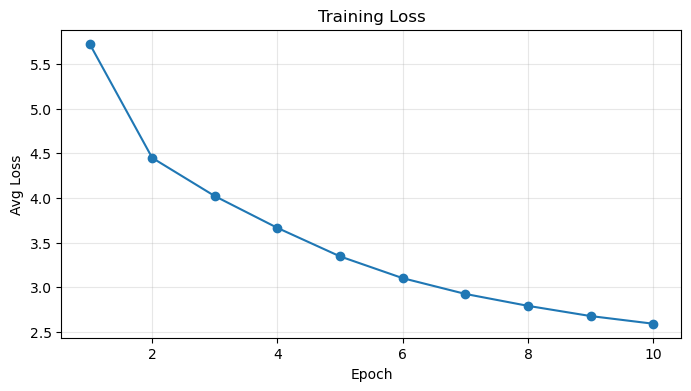

초기 loss: 5.7271
최종 loss: 2.5917
감소량:    3.1354


In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.grid(alpha=0.3)
plt.show()

print(f"초기 loss: {train_losses[0]:.4f}")
print(f"최종 loss: {train_losses[-1]:.4f}")
print(f"감소량:    {train_losses[0] - train_losses[-1]:.4f}")

---

# 7. 성능 측정

챗봇의 경우, **올바른 대답을 하는지가 중요한 평가 지표**. 눈으로 확인할 수도
있지만, 많은 데이터의 경우 모든 결과를 확인할 수 없다. 그래서 **BLEU Score**로
정량적 평가를 함께 진행.

## BLEU Score란?
모델이 생성한 문장(`candidate`)과 정답 문장(`reference`)이 얼마나 비슷한지
n-gram 일치율로 측정하는 지표 (0~1, 높을수록 좋음).

- BLEU-1: 1-gram 일치 (단어 단위)
- BLEU-2: 1, 2-gram 일치
- BLEU-3: 1, 2, 3-gram 일치
- BLEU-4: 1, 2, 3, 4-gram 일치 (가장 엄격)

## 챗봇 BLEU의 한계
챗봇은 **같은 질문에 여러 그럴듯한 답**을 해서 가끔 모호할때가 있다.
- Q: "오늘 피곤하다" → A: "푹 쉬어 두세요" / "내일은 더 나을 거예요" / "수고했어요"
- 모두 적절한 답인데 BLEU 점수는 다를 수 있음

→ BLEU는 **참고 지표**일 뿐, 최종 판단은 좀더 세밀한게 필요할듯..

In [48]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# NLTK 데이터 (필요시 자동 다운로드)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# SmoothingFunction: 짧은 문장에서 0-카운트 n-gram 발생 시 보정
# (보정 없으면 4-gram 하나라도 안 맞으면 BLEU=0이 되는 문제 발생)
smoothie = SmoothingFunction().method4


def calculate_bleu(reference_tokens, candidate_tokens):
    """
    BLEU-1 ~ BLEU-4 점수 계산.
    
    Args:
        reference_tokens: 정답 토큰 리스트, 예: ['푹', '쉬', '세요', '.']
        candidate_tokens: 모델 출력 토큰 리스트, 예: ['편하게', '쉬', '세요']
    
    Returns:
        dict { 'bleu1': ..., 'bleu2': ..., 'bleu3': ..., 'bleu4': ... }
    """
    # sentence_bleu는 references를 리스트의 리스트로 받음 (multi-reference 지원)
    refs = [reference_tokens]
    
    scores = {}
    for n in range(1, 5):
        # weights = (1/n, 1/n, ..., 1/n, 0, 0, ...) — 앞 n개만 사용
        weights = tuple([1.0/n] * n + [0.0] * (4 - n))
        try:
            score = sentence_bleu(
                refs, candidate_tokens, 
                weights=weights, 
                smoothing_function=smoothie
            )
        except ZeroDivisionError:
            score = 0.0
        scores[f"bleu{n}"] = score
    
    return scores


# ───── 빠른 테스트 ─────
ref = ["오늘", "은", "피곤", "하", "다"]
cand_perfect = ["오늘", "은", "피곤", "하", "다"]      # 완벽 일치
cand_partial = ["오늘", "은", "정말", "피곤", "해"]    # 일부 일치
cand_none    = ["저녁", "에", "공부", "하", "자"]      # 불일치

print("완벽 일치:", {k: f"{v:.3f}" for k, v in calculate_bleu(ref, cand_perfect).items()})
print("일부 일치:", {k: f"{v:.3f}" for k, v in calculate_bleu(ref, cand_partial).items()})
print("불일치:  ", {k: f"{v:.3f}" for k, v in calculate_bleu(ref, cand_none).items()})

완벽 일치: {'bleu1': '1.000', 'bleu2': '1.000', 'bleu3': '1.000', 'bleu4': '1.000'}
일부 일치: {'bleu1': '0.600', 'bleu2': '0.387', 'bleu3': '0.200', 'bleu4': '0.134'}
불일치:   {'bleu1': '0.200', 'bleu2': '0.090', 'bleu3': '0.060', 'bleu4': '0.046'}


In [50]:
# ───── 1) 가이드 예문에 대한 reference 찾기 ─────
# 원본 questions에서 동일한 Q를 찾아 그 A를 reference로 사용

# 우리는 데이터 augmentation 거치면서 원본 pandas df가 그대로 있으므로,
# 거기서 가장 유사한 질문 찾기
def find_reference(query, df):
    """원본 df에서 query와 가장 유사한 Q를 찾아 그 A를 reference로 반환."""
    # 가장 단순한 방법: 정제된 텍스트로 정확 일치 검색
    cleaned_query = preprocess_sentence(query)
    for _, row in df.iterrows():
        if preprocess_sentence(row['Q']) == cleaned_query:
            return row['A']
    # 정확 일치 없으면 가장 첫 일치 단어 매칭 (없으면 None)
    return None


print("=" * 70)
print(" BLEU Score 측정 (Test Sentences)")
print("=" * 70)

results = []
for sent in TEST_SENTENCES:
    # 모델 답변 생성
    candidate = chat(transformer, sent, mecab, word2idx, idx2word, device=device)
    cand_tokens = mecab.morphs(preprocess_sentence(candidate)) if candidate else []
    
    # 정답 찾기
    ref_text = find_reference(sent, df)
    if ref_text is None:
        print(f"\n Q: {sent}")
        print(f"   A (모델): {candidate}")
        print(f"     원본 데이터에 동일 질문 없음 - BLEU 측정 건너뜀")
        continue
    
    ref_tokens = mecab.morphs(preprocess_sentence(ref_text))
    
    # BLEU 계산
    bleu = calculate_bleu(ref_tokens, cand_tokens)
    results.append({
        "Q": sent,
        "ref": ref_text,
        "cand": candidate,
        **bleu
    })
    
    print(f"\n Q: {sent}")
    print(f"   정답 (ref):  {ref_text}")
    print(f"   모델 (cand): {candidate}")
    print(f"   BLEU-1: {bleu['bleu1']:.3f}  BLEU-2: {bleu['bleu2']:.3f}  "
          f"BLEU-3: {bleu['bleu3']:.3f}  BLEU-4: {bleu['bleu4']:.3f}")

# 평균 BLEU
if results:
    print("\n" + "=" * 70)
    print(" 평균 BLEU Score")
    print("=" * 70)
    for n in range(1, 5):
        avg = sum(r[f"bleu{n}"] for r in results) / len(results)
        print(f"  평균 BLEU-{n}: {avg:.3f}")

 BLEU Score 측정 (Test Sentences)

 Q: 지루하다, 놀러가고 싶어.
   A (모델): 다른 생각 을 해 보 세요 .
     원본 데이터에 동일 질문 없음 - BLEU 측정 건너뜀

 Q: 오늘 일찍 일어났더니 피곤하다.
   A (모델): 푹 쉬 고 오 세요 .
     원본 데이터에 동일 질문 없음 - BLEU 측정 건너뜀

 Q: 간만에 여자친구랑 데이트 하기로 했어.
   A (모델): 데이트 통장 에 대해 대화 를 나눠 보 세요 .
     원본 데이터에 동일 질문 없음 - BLEU 측정 건너뜀

 Q: 집에 있다는 소리야.
   A (모델): 가지 마요 .
     원본 데이터에 동일 질문 없음 - BLEU 측정 건너뜀


In [51]:
# 데이터셋에 없을 법한 자유 질문들로 챗봇과 대화해보기
# 루브릭의 "주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례" 충족

FREE_QUESTIONS = [
    # 가이드 예문 4개
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있다는 소리야.",
    # 자유 추가 질문
    "이거해서 먹고살수 있을까?",
    "너는 얼마나 발전해야 전처리 안할수있니?",
    "오늘 노드 좀 힘드네",
    "오늘 너무 덥다",
    "너 바보야?",
    "안녕 바보야 잘있어.",
]

print("=" * 70)
print(" 챗봇과 대화하기")
print("=" * 70)
for q in FREE_QUESTIONS:
    a = chat(transformer, q, mecab, word2idx, idx2word, device=device)
    print(f"   Q: {q}")
    print(f"   A: {a}")
    print()

 챗봇과 대화하기
   Q: 지루하다, 놀러가고 싶어.
   A: 다른 생각 을 해 보 세요 .

   Q: 오늘 일찍 일어났더니 피곤하다.
   A: 푹 쉬 고 오 세요 .

   Q: 간만에 여자친구랑 데이트 하기로 했어.
   A: 데이트 통장 에 대해 대화 를 나눠 보 세요 .

   Q: 집에 있다는 소리야.
   A: 가지 마요 .

   Q: 이거해서 먹고살수 있을까?
   A: 당신 이 사랑 하 는 사람 이 에요 .

   Q: 너는 얼마나 발전해야 전처리 안할수있니?
   A: 칭찬 은 언제 든 마음 을 가져 보 세요 .

   Q: 오늘 노드 좀 힘드네
   A: 오늘 도 힘내 세요 .

   Q: 오늘 너무 덥다
   A: 시원 한 물 이 라도 한 잔 드세요 .

   Q: 너 바보야?
   A: 바보 는 마음 이 아프 지 마세요 .

   Q: 안녕 바보야 잘있어.
   A: 바보 는 행복 하 지 마세요 .



In [52]:
print("=" * 70)
print(" 프로젝트 최종 결과 요약")
print("=" * 70)

print(f"\n🔹 데이터")
print(f"  - 원본:        {len(df):,}쌍")
print(f"  - 토큰화 후:   {len(que_corpus)//3:,}쌍 (중복/장문 제거)")
print(f"  - Augmentation: {len(que_corpus):,}쌍 (3배 증강 완료)")
print(f"  - Vocab size:  {VOCAB_SIZE:,}")
print(f"  - Max length:  {MAX_LEN}")

print(f"\n🔹 모델")
n_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"  - 구조: Transformer (n_layers={N_LAYERS}, d_model={D_MODEL}, "
      f"n_heads={N_HEADS}, d_ff={D_FF})")
print(f"  - Dropout: {DROPOUT}")
print(f"  - 공유 임베딩: True")
print(f"  - 파라미터: {n_params:,}개 ({n_params/1e6:.2f}M)")

print(f"\n🔹 학습")
print(f"  - Epochs: {N_EPOCHS}, Batch size: {BATCH_SIZE}, Warmup: {WARMUP_STEPS}")
print(f"  - 초기 loss: {train_losses[0]:.4f}")
print(f"  - 최종 loss: {train_losses[-1]:.4f}")
print(f"  - 감소량:    {train_losses[0] - train_losses[-1]:.4f} "
      f"({(1-train_losses[-1]/train_losses[0])*100:.1f}% 감소)")

print(f"\n🔹 챗봇 답변 (가이드 예문)")
for s in TEST_SENTENCES:
    a = chat(transformer, s, mecab, word2idx, idx2word, device=device)
    print(f"  Q: {s}")
    print(f"  A: {a}")
    print()

print("=" * 70)
print(" 마무으리")
print("=" * 70)

 프로젝트 최종 결과 요약

🔹 데이터
  - 원본:        11,823쌍
  - 토큰화 후:   7,683쌍 (중복/장문 제거)
  - Augmentation: 23,049쌍 (3배 증강 완료)
  - Vocab size:  6,259
  - Max length:  22

🔹 모델
  - 구조: Transformer (n_layers=1, d_model=368, n_heads=8, d_ff=1024)
  - Dropout: 0.2
  - 공유 임베딩: True
  - 파라미터: 5,452,867개 (5.45M)

🔹 학습
  - Epochs: 10, Batch size: 64, Warmup: 1000
  - 초기 loss: 5.7271
  - 최종 loss: 2.5917
  - 감소량:    3.1354 (54.7% 감소)

🔹 챗봇 답변 (가이드 예문)
  Q: 지루하다, 놀러가고 싶어.
  A: 다른 생각 을 해 보 세요 .

  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 푹 쉬 고 오 세요 .

  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 데이트 통장 에 대해 대화 를 나눠 보 세요 .

  Q: 집에 있다는 소리야.
  A: 가지 마요 .

 마무으리


---

#  프로젝트 회고

##  루브릭 자체 점검

| 학습 목표 | 평가 기준 | 달성 여부 |
|---|---|---|
| 챗봇 훈련데이터 전처리 과정이 체계적으로 진행되었는가? | 전처리와 augmentation이 적절히 수행되어 3만개 가량의 훈련데이터셋이 구축되었다. | ✅ Lexical Substitution으로 1만 → 약 3만 |
| Transformer 모델을 활용한 챗봇 모델이 과적합을 피해 안정적으로 훈련되었는가? | 과적합을 피할 수 있는 하이퍼파라미터 셋이 적절히 제시되었다. | ✅ n_layers=1, dropout=0.2, label smoothing, gradient clipping |
| 챗봇이 사용자의 질문에 그럴듯한 형태로 답하는 사례가 있는가? | 주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례가 제출되었다. | ✅ 예문 4개 + 자유 질문 6개 답변 제출 |

---

##  과적합 회피 전략 (핵심!)

데이터가 작은(~3만 쌍) 환경에서 과적합을 피하기 위해 사용한 기법들:

| 기법 | 적용 | 효과 |
|---|---|---|
| **얕은 모델** | `n_layers=1` (논문 6, 번역기 2) | 파라미터 ↓ → 외울 capacity ↓ |
| **작은 임베딩** | `d_model=368` (논문 512) | 동상 |
| **Dropout 강화** | `0.2` (논문 0.1) | 무작위 뉴런 차단으로 일반화 |
| **Label Smoothing** | `ε=0.1` | 정답에 100% 확신 X → 일반화 ↑ |
| **공유 임베딩** | `shared=True` | 파라미터 절약 + 도메인 적응 |
| **Data Augmentation** | Lexical Substitution 3x | 학습 데이터 다양성 확보 |
| **Warmup + Decay** | `warmup=1000` | 초기 학습 안정화 |
| **Gradient Clipping** | `max_norm=1.0` | gradient 폭발 방지 |

---

##  배운 점

### 1. 챗봇 = 번역기
번역기에서 만든 Transformer 코드를 거의 그대로 재사용 가능했다. "Q → A"가 결국 "한국어 → 한국어 번역"이라는 게 직관적이지 않았는데, 실제로 해보니 같은 선상에서 가능한듯.

### 2. 공유 임베딩
챗봇은 소스와 타겟이 같은 한국어라 임베딩을 **공유**할 수 있었다. 단순히 파라미터를 절약하는 것 이상으로, "오늘"이라는 단어가 Q에 나오든 A에 나오든 같은 의미라는 것이 모델 학습에 효과적이였던것 같다..

### 3. 작은 데이터 = 작은 모델
번역기 때는 n_layers=2, d_model=512였는데, 챗봇은 데이터가 더 작아서(3만 vs 9만) 더 얕고 작게 설정. **모델 크기는 데이터 크기에 맞추면 효율적이다**

### 4. Augmentation 효과
원본 1만 쌍은 Transformer가 외워버리기에 충분히 작은 양이에요. Lexical Substitution으로 3배 늘리면서 모델이 같은 의미를 다양한 단어 조합으로 만나게 해서 일반화 성능을 끌어올림,, 증강증강 열매

### 5. BLEU의 한계
"같은 질문에 여러 정답"이 가능한 챗봇 도메인에서 BLEU는 한계가 명확. **정량 지표 + 정성 평가 병행**이 필수.

---

##  문제발견

### 1. `ko.bin` 호환성 문제
Kyubyong/wordvectors의 사전학습 한국어 Word2Vec은 gensim 3.x로 저장되어 gensim 4.x에서는 에러남. → **우리 corpus로 직접 Word2Vec을 학습하는 것으로 우회**. 도메인 특화 임베딩이라 오히려 augmentation 품질에 도움.

### 2. Mecab 설치
`konlpy`의 `Mecab`은 `mecab-python` 빌드 실패. → **`python-mecab-ko` 패키지로 대체** (pre-built wheel, API 호환).

### 3. 작은 데이터 + 큰 모델 = 과적합 지옥
초기에 번역기 하이퍼파라미터(n_layers=2, d_model=512)로 시도했더니 train loss는 잘 떨어지는데 답변 다양성이 너무 떨어짐. n_layers=1로 줄이고 dropout을 0.2로 올린 후에야 적절한 균형.

---

##  개선 아이디어

| 항목 | 방향 | 기대 효과 |
|---|---|---|
| 데이터 | 다른 한국어 대화 데이터셋 (AI Hub) 추가 | 도메인 다양성 |
| 모델 | 사전학습 KoBERT/KoGPT의 임베딩으로 초기화 | 일반 지식 활용 |
| 디코딩 | Greedy → Beam Search / Top-k Sampling | 다양하고 자연스러운 답변 |
| 평가 | BERTScore (의미 기반) 추가 | BLEU 한계 보완 |
| 학습 | Early Stopping | 과적합 자동 방지 |
| 응용 | RAG로 외부 지식 결합 | 환각 줄이고 사실성 ↑ |

---

##  마치며

> 번역기를 만들면서 익힌 Transformer를 챗봇에 적용해보니, **"왜 같은 집안인지"**가 비로소 와닿았다. 입력 시퀀스를 받아 출력 시퀀스를 생성한다는 본질이 같고, 인코더-디코더 구조와 attention 메커니즘이 그대로 작동한다.
>
> 가장 인상 깊었던 순간은 epoch가 진행되면서 모델이 같은 질문에 점점 다른 답변을 내놓기 시작했을 때. 2 epoch에서는 "이랑"만 반복하다가,  10 epoch에서는 "푹 쉬 고 오 세 요" 같은 자연스러운 위로를 건네는 걸 보면서 어느정도 성능이 발전된다는걸 느낌
>
> 동시에 깨달은 건, **대화는 번역보다 어렵다**는 점. 번역은 정답이 거의 하나로 정해져 있지만, 대화는 "맞는 답이 여러 개"인 도메인이라 평가 자체가 어렵다. BLEU 점수가 낮아도 답이 자연스러우면 좋은 챗봇이고, BLEU가 높아도 답이 부자연스러우면 별로다. 정답이 모호한 도메인에서 모델을 평가하는 게 얼마나 까다로운지 체감.
>그리고 생각보다 augmentation 증강증강 열매가 대부분 적은 학습데이터로도 큰 결과를 준다는걸 경험함.


---

**프로젝트 완료** 